
# CAPSTONE PROJECT 1
## Working with NumPy Matrices (Multidimensional Data)

**Dataset:** National Health and Nutrition Examination Survey (NHANES), 2017–March 2020 body measurements  
**Tools:** Python, NumPy, Matplotlib, SciPy, Seaborn, Pandas

### Executive Summary
This report analyses adult male and female body-measurement data using NumPy matrices. The analysis covers weight distributions, descriptive statistics, Body Mass Index (BMI), standardisation, pairwise correlations, waist-to-height and waist-to-hip ratios, and the participants with the lowest and highest BMI values.

The notebook is organised as a formal report. Each analytical section begins with a short explanation of its purpose, followed by reproducible Python code and a concise interpretation of the resulting output.

> **Source:** The project instructions specify the two NHANES excerpts `nhanes_adult_male_bmx_2020.csv` and `nhanes_adult_female_bmx_2020.csv` from Marek Gagolewski's teaching-data repository. The files contain seven body measurements: weight, standing height, upper arm length, upper leg length, arm circumference, hip circumference, and waist circumference.



## 1. Import Libraries and Define the Data Sources

The first step is to import the numerical, statistical, plotting, and tabular libraries required for the analysis. The CSV files are loaded directly from the specified public repository so that the notebook is reproducible and does not depend on manually copied data.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Make plots readable in a report.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

MALE_URL = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_male_bmx_2020.csv"
FEMALE_URL = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_female_bmx_2020.csv"

MALE_FILE = "nhanes_adult_male_bmx_2020.csv"
FEMALE_FILE = "nhanes_adult_female_bmx_2020.csv"

print("Libraries imported successfully.")


Libraries imported successfully.


### Google Colab Compatibility Note

This notebook is designed to run directly in Google Colab. The NHANES files are loaded from the specified public GitHub repository using `pandas.read_csv(..., comment="#")`, which correctly handles the descriptive comment lines and CSV header in these files.

If Colab asks for a runtime/kernel, choose **Python 3** and then use **Runtime → Run all**.



The imports provide all functionality required for the project. NumPy handles the matrices and calculations, Matplotlib handles the required histograms and boxplots, SciPy provides statistical measures and correlation coefficients, and Seaborn/Pandas support the scatterplot matrix.



## 2. Load the Male and Female NHANES Matrices

The project requires the two CSV files to be read as NumPy matrices named `male` and `female`. Comment lines beginning with `#` are ignored, and the header row is skipped. The resulting matrices contain the seven body measurements specified in the project instructions.


In [2]:
# Load the two NHANES CSV files directly from the project-specified repository.
# pandas.read_csv is used first because the files contain descriptive comment
# lines followed by a CSV header. This avoids the header/comment parsing issue
# that can occur with np.loadtxt in Google Colab.

male_df = pd.read_csv(MALE_URL, comment="#")
female_df = pd.read_csv(FEMALE_URL, comment="#")

# Convert the seven measurement columns to NumPy arrays.
male_data = male_df.to_numpy(dtype=float)
female_data = female_df.to_numpy(dtype=float)

# Use NumPy matrix objects as requested by the assignment.
male = np.matrix(male_data)
female = np.matrix(female_data)

column_names = [
    "Weight (kg)",
    "Standing Height (cm)",
    "Upper Arm Length (cm)",
    "Upper Leg Length (cm)",
    "Arm Circumference (cm)",
    "Hip Circumference (cm)",
    "Waist Circumference (cm)",
]

print("Male matrix shape:   ", male.shape)
print("Female matrix shape: ", female.shape)
print("\nNumber of male participants:  ", male.shape[0])
print("Number of female participants:", female.shape[0])
print("\nColumn order:")
for i, name in enumerate(column_names, start=1):
    print(f"{i}. {name}")


Male matrix shape:    (4081, 7)
Female matrix shape:  (4221, 7)

Number of male participants:   4081
Number of female participants: 4221

Column order:
1. Weight (kg)
2. Standing Height (cm)
3. Upper Arm Length (cm)
4. Upper Leg Length (cm)
5. Arm Circumference (cm)
6. Hip Circumference (cm)
7. Waist Circumference (cm)



The dimensions printed above confirm that both datasets have seven original measurement columns. Keeping the same column order is important because all later calculations refer to these positions.



## 3. Compare Male and Female Weight Distributions with Histograms

The next analysis compares the distributions of female and male weights. The project specifically requires two histograms on one figure, with female weights in the top subplot and male weights in the bottom subplot. Identical x-axis limits are used so that the distributions can be compared on the same numerical scale.


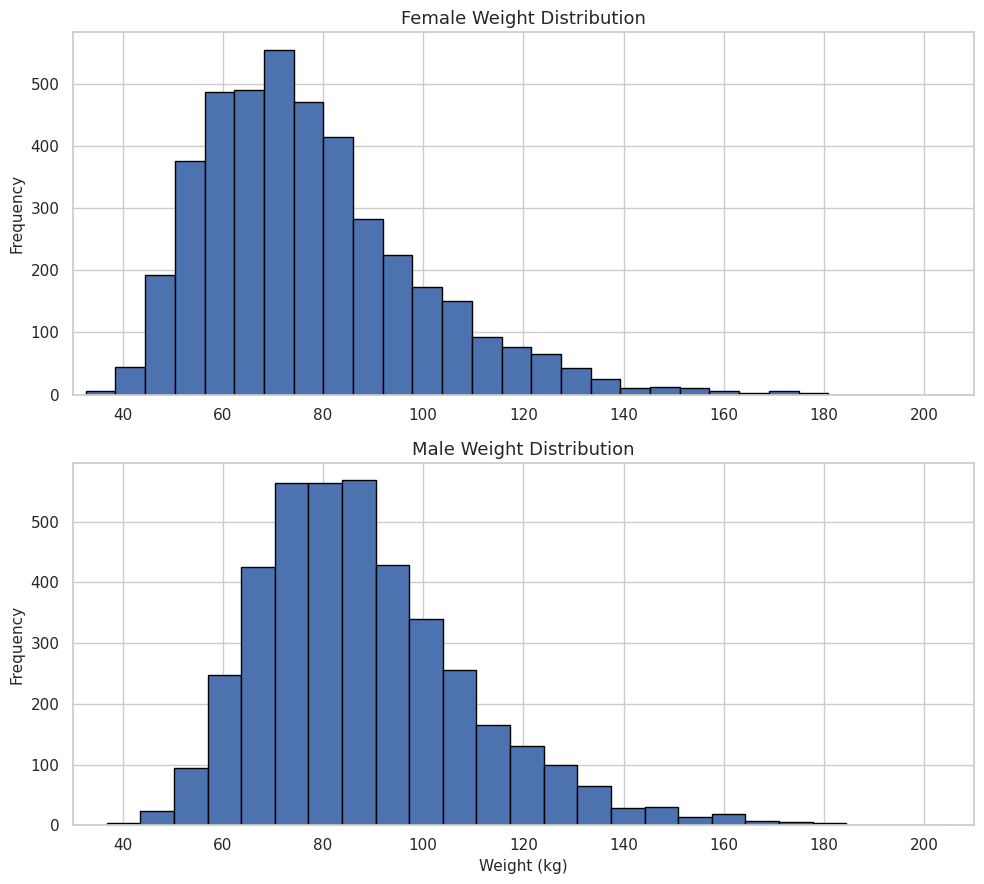

Common x-axis limits: 30 kg to 210 kg.


In [3]:
female_weights = np.asarray(female[:, 0]).ravel()
male_weights = np.asarray(male[:, 0]).ravel()

# Determine common x-axis limits from both distributions.
combined_weights = np.concatenate([female_weights, male_weights])
weight_min = np.floor(combined_weights.min() / 10) * 10
weight_max = np.ceil(combined_weights.max() / 10) * 10

plt.figure(figsize=(10, 9))

# Top subfigure: female weights
plt.subplot(2, 1, 1)
plt.hist(female_weights, bins=25, edgecolor="black")
plt.xlim(weight_min, weight_max)
plt.title("Female Weight Distribution")
plt.ylabel("Frequency")

# Bottom subfigure: male weights
plt.subplot(2, 1, 2)
plt.hist(male_weights, bins=25, edgecolor="black")
plt.xlim(weight_min, weight_max)
plt.title("Male Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"Common x-axis limits: {weight_min:.0f} kg to {weight_max:.0f} kg.")



Using the same horizontal scale makes the comparison visually fair. The two histograms show the centre, spread, and shape of the male and female weight distributions. The numerical summary in the next section provides a more precise comparison than visual inspection alone.



## 4. Box-and-Whisker Plot of Male and Female Weights

A boxplot is used to compare the two weight distributions compactly. The median is shown by the central line, the box represents the interquartile range, and the whiskers and individual points indicate the broader spread and potential extreme observations.


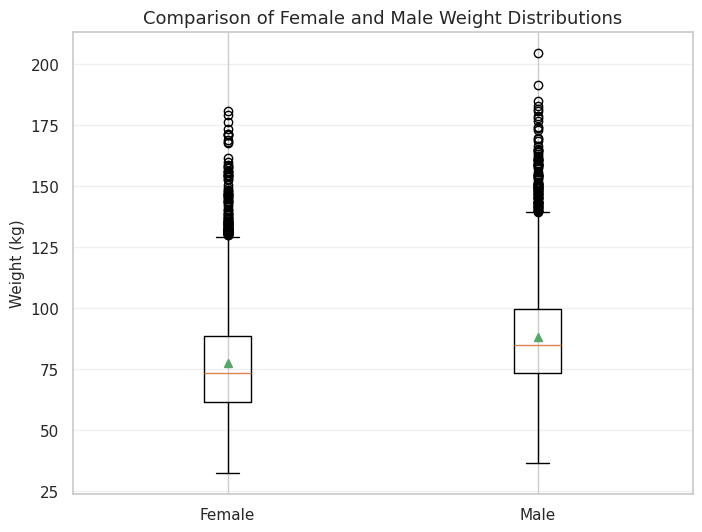

Female median weight: 73.60 kg
Male median weight:   85.00 kg


In [4]:
plt.figure(figsize=(8, 6))
plt.boxplot(
    [female_weights, male_weights],
    tick_labels=["Female", "Male"],
    showmeans=True
)
plt.ylabel("Weight (kg)")
plt.title("Comparison of Female and Male Weight Distributions")
plt.grid(axis="y", alpha=0.3)
plt.show()

print(f"Female median weight: {np.median(female_weights):.2f} kg")
print(f"Male median weight:   {np.median(male_weights):.2f} kg")



The boxplot allows the location and dispersion of the two groups to be compared directly. A higher median indicates a greater typical body weight, while a taller box indicates a larger interquartile spread. Points beyond the whiskers indicate observations that are unusually distant from the central part of the distribution.



## 5. Basic Numerical Aggregates and Distribution Shape

To complement the plots, the following analysis calculates measures of location, dispersion, and shape for male and female weights. The measures include the mean, median, minimum, maximum, variance, standard deviation, quartiles, interquartile range, skewness, and excess kurtosis.


In [5]:

def descriptive_statistics(values):
    values = np.asarray(values, dtype=float)
    q1, median, q3 = np.percentile(values, [25, 50, 75])
    return {
        "Count": len(values),
        "Mean": np.mean(values),
        "Median": median,
        "Minimum": np.min(values),
        "Q1": q1,
        "Q3": q3,
        "Maximum": np.max(values),
        "Variance": np.var(values, ddof=1),
        "Std. Deviation": np.std(values, ddof=1),
        "IQR": q3 - q1,
        "Skewness": stats.skew(values, bias=False),
        "Excess Kurtosis": stats.kurtosis(values, bias=False),
    }

weight_stats = pd.DataFrame({
    "Female": descriptive_statistics(female_weights),
    "Male": descriptive_statistics(male_weights)
}).T

display(weight_stats.round(3))

female_skew = weight_stats.loc["Female", "Skewness"]
male_skew = weight_stats.loc["Male", "Skewness"]

print("\nInterpretation:")
print(f"Female mean weight = {weight_stats.loc['Female', 'Mean']:.2f} kg; "
      f"male mean weight = {weight_stats.loc['Male', 'Mean']:.2f} kg.")
print(f"Female standard deviation = {weight_stats.loc['Female', 'Std. Deviation']:.2f} kg; "
      f"male standard deviation = {weight_stats.loc['Male', 'Std. Deviation']:.2f} kg.")

for label, skew in [("female", female_skew), ("male", male_skew)]:
    if skew > 0.5:
        shape = "positively (right) skewed"
    elif skew < -0.5:
        shape = "negatively (left) skewed"
    else:
        shape = "approximately symmetric"
    print(f"The {label} weight distribution is {shape} (skewness = {skew:.3f}).")

more_disp = "female" if weight_stats.loc["Female", "Std. Deviation"] > weight_stats.loc["Male", "Std. Deviation"] else "male"
print(f"The group with the larger standard deviation is the {more_disp} group.")


,Count,Mean,Median,Minimum,Q1,Q3,Maximum,Variance,Std. Deviation,IQR,Skewness,Excess Kurtosis
Female,4221.0,77.404,73.6,32.6,61.6,88.7,180.9,464.190,21.545,27.1,1.034,1.404
Male,4081.0,88.365,85.0,36.8,73.3,99.8,204.6,458.883,21.422,26.5,0.985,1.478



Interpretation:
Female mean weight = 77.40 kg; male mean weight = 88.36 kg.
Female standard deviation = 21.55 kg; male standard deviation = 21.42 kg.
The female weight distribution is positively (right) skewed (skewness = 1.034).
The male weight distribution is positively (right) skewed (skewness = 0.985).
The group with the larger standard deviation is the female group.



The descriptive statistics quantify the differences visible in the earlier figures. In particular, the mean and median describe central location, the standard deviation and IQR describe dispersion, and skewness describes asymmetry. Positive skewness indicates a longer upper tail, while negative skewness indicates a longer lower tail. Kurtosis is reported as excess kurtosis, where values around zero indicate a shape broadly similar to a normal distribution in terms of tail weight.



## 6. Add Body Mass Index (BMI) to the Female Matrix

BMI is calculated as weight in kilograms divided by height in metres squared:

**BMI = weight (kg) / height (m)²**

The female matrix is extended from seven to eight columns by adding BMI as its eighth column, as required by the project.


In [6]:

female_weight = np.asarray(female[:, 0]).ravel()
female_height_m = np.asarray(female[:, 1]).ravel() / 100.0

female_bmi = female_weight / (female_height_m ** 2)

female = np.hstack([female, female_bmi.reshape(-1, 1)])

female_column_names = column_names + ["BMI"]

print("Updated female matrix shape:", female.shape)
print(f"Mean female BMI: {female_bmi.mean():.2f}")
print(f"Minimum female BMI: {female_bmi.min():.2f}")
print(f"Maximum female BMI: {female_bmi.max():.2f}")


Updated female matrix shape: (4221, 8)
Mean female BMI: 30.10
Minimum female BMI: 14.20
Maximum female BMI: 67.04



The female matrix now contains eight columns, with BMI appended as the final column. BMI is derived consistently from the original weight and standing-height measurements, with height converted from centimetres to metres before squaring.



## 7. Standardise All Female Measurements to Create `zfemale`

Standardisation converts each column to a z-score using:

**z = (x − column mean) / column standard deviation**

This places the different measurements on a common scale. The resulting matrix is named `zfemale`, as required by the project.


In [7]:

female_array = np.asarray(female, dtype=float)

female_means = female_array.mean(axis=0)
female_stds = female_array.std(axis=0, ddof=0)

# Guard against division by zero if a future version of the data contains
# a constant column.
if np.any(female_stds == 0):
    raise ValueError("At least one female measurement column has zero variance.")

zfemale = (female_array - female_means) / female_stds
zfemale = np.matrix(zfemale)

print("zfemale shape:", zfemale.shape)

check_means = np.asarray(zfemale).mean(axis=0)
check_stds = np.asarray(zfemale).std(axis=0)

verification = pd.DataFrame({
    "Variable": female_column_names,
    "Mean of z-scores": check_means,
    "Std. dev. of z-scores": check_stds
})
display(verification.round(6))


zfemale shape: (4221, 8)


,Variable,Mean of z-scores,Std. dev. of z-scores
0,Weight (kg),0.0,1.0
1,Standing Height (cm),0.0,1.0
2,Upper Arm Length (cm),-0.0,1.0
3,Upper Leg Length (cm),-0.0,1.0
4,Arm Circumference (cm),0.0,1.0
5,Hip Circumference (cm),-0.0,1.0
6,Waist Circumference (cm),0.0,1.0
7,BMI,-0.0,1.0



The verification table should show means very close to 0 and standard deviations very close to 1 for every column. This confirms that the standardisation was applied column-by-column rather than across the entire matrix.



## 8. Scatterplot Matrix and Pearson/Spearman Correlations

The project asks for a scatterplot matrix of the standardised female height, weight, waist circumference, hip circumference, and BMI variables. Because standardisation does not change the underlying correlation structure, the Pearson and Spearman correlations can be calculated directly from the corresponding standardised variables.

Pearson correlation measures linear association. Spearman correlation measures the strength of a monotonic relationship based on ranks and is less sensitive to non-normality and extreme values.


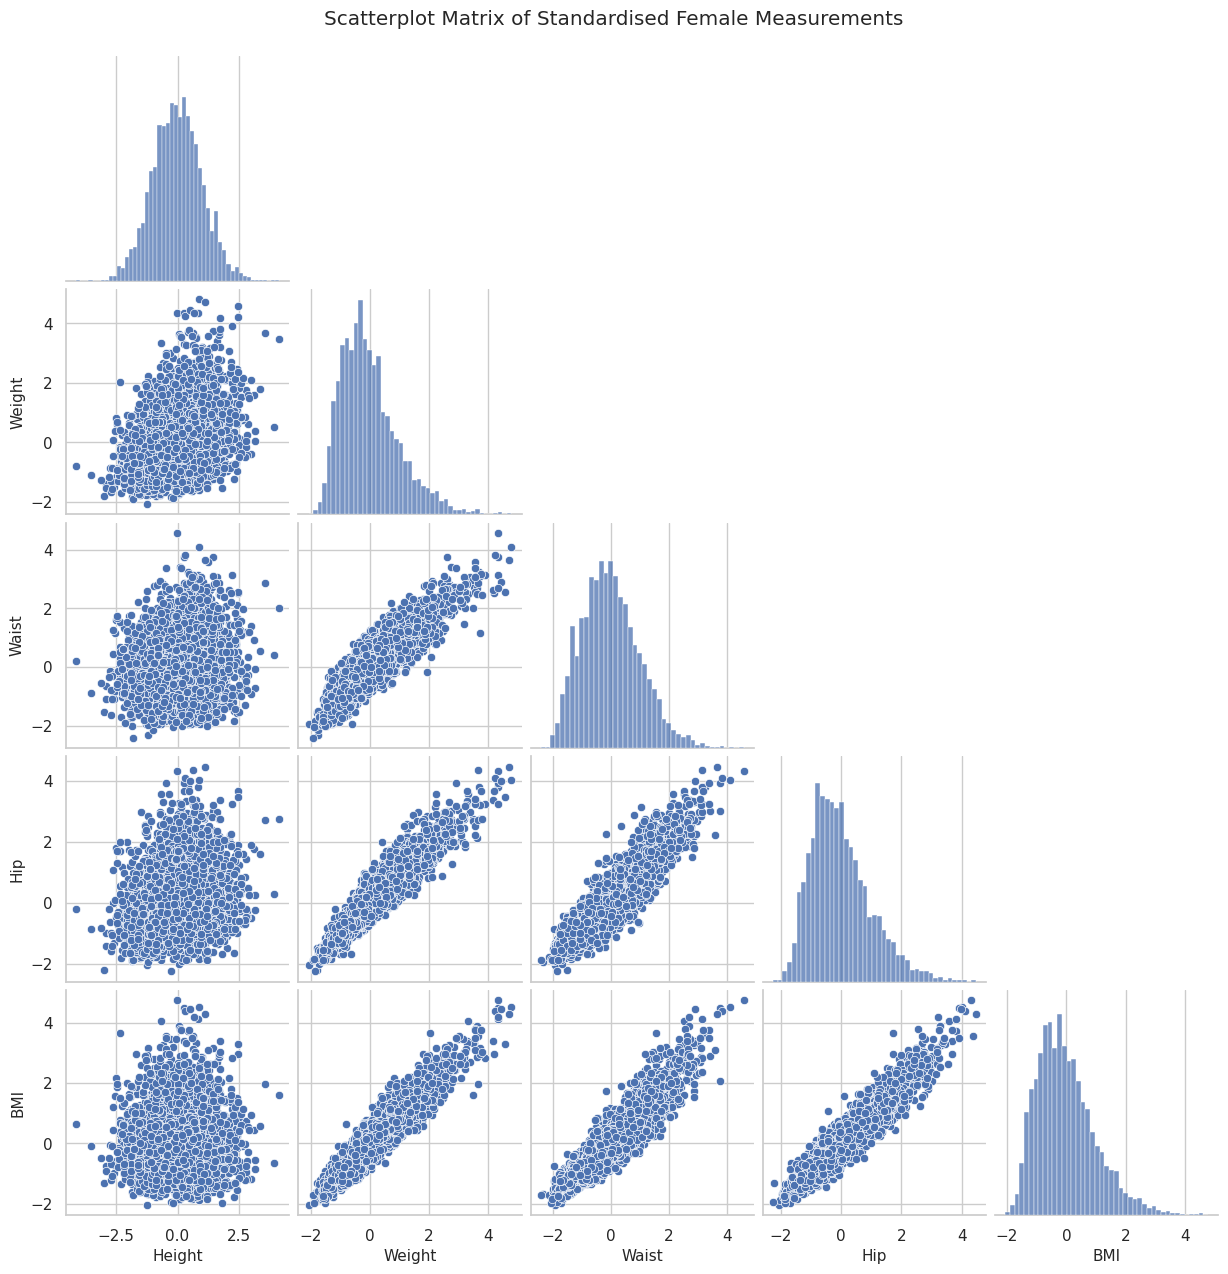

Pearson correlation matrix:


,Height,Weight,Waist,Hip,BMI
Height,1.000,0.345,0.127,0.203,0.033
Weight,0.345,1.000,0.905,0.947,0.946
Waist,0.127,0.905,1.000,0.897,0.921
Hip,0.203,0.947,0.897,1.000,0.944
BMI,0.033,0.946,0.921,0.944,1.000


Spearman correlation matrix:


,Height,Weight,Waist,Hip,BMI
Height,1.000,0.339,0.109,0.205,0.020
Weight,0.339,1.000,0.900,0.947,0.938
Waist,0.109,0.900,1.000,0.888,0.923
Hip,0.205,0.947,0.888,1.000,0.934
BMI,0.020,0.938,0.923,0.934,1.000


Strongest absolute Pearson association: Weight vs Hip (r = 0.947).
Strongest absolute Spearman association: Weight vs Hip (rho = 0.947).


In [8]:

pair_indices = [1, 0, 6, 5, 7]
pair_names = ["Height", "Weight", "Waist", "Hip", "BMI"]

pair_df = pd.DataFrame(
    np.asarray(zfemale)[:, pair_indices],
    columns=pair_names
)

sns.pairplot(pair_df, corner=True, diag_kind="hist")
plt.suptitle("Scatterplot Matrix of Standardised Female Measurements", y=1.02)
plt.show()

pearson_corr = pair_df.corr(method="pearson")
spearman_corr = pair_df.corr(method="spearman")

print("Pearson correlation matrix:")
display(pearson_corr.round(3))

print("Spearman correlation matrix:")
display(spearman_corr.round(3))

# Find the strongest non-self correlation for each method.
def strongest_pair(corr):
    corr_abs = corr.abs().copy()
    np.fill_diagonal(corr_abs.values, np.nan)
    stacked = corr_abs.stack()
    first_pair = stacked.idxmax()
    return first_pair, corr.loc[first_pair]

p_pair, p_value = strongest_pair(pearson_corr)
s_pair, s_value = strongest_pair(spearman_corr)

print(f"Strongest absolute Pearson association: {p_pair[0]} vs {p_pair[1]} "
      f"(r = {p_value:.3f}).")
print(f"Strongest absolute Spearman association: {s_pair[0]} vs {s_pair[1]} "
      f"(rho = {s_value:.3f}).")



The correlation matrices quantify the relationships visible in the scatterplot matrix. Correlations close to +1 indicate a strong positive association, correlations close to −1 indicate a strong negative association, and values close to 0 indicate little linear or monotonic association. Similar Pearson and Spearman values suggest that the relationship is reasonably stable under both linear and rank-based measurement.



## 9. Add Waist-to-Height and Waist-to-Hip Ratios

Two additional measures are calculated for both sexes:

- **Waist-to-height ratio (WHtR) = waist circumference / standing height**
- **Waist-to-hip ratio (WHR) = waist circumference / hip circumference**

Both ratios are dimensionless because the numerator and denominator use the same units.


In [9]:

# Column indices in the original matrices:
# weight=0, height=1, hip=5, waist=6

male_height = np.asarray(male[:, 1]).ravel()
male_hip = np.asarray(male[:, 5]).ravel()
male_waist = np.asarray(male[:, 6]).ravel()

female_height = np.asarray(female[:, 1]).ravel()
female_hip = np.asarray(female[:, 5]).ravel()
female_waist = np.asarray(female[:, 6]).ravel()

male_whtr = male_waist / male_height
male_whr = male_waist / male_hip

female_whtr = female_waist / female_height
female_whr = female_waist / female_hip

male = np.hstack([male, male_whtr.reshape(-1, 1), male_whr.reshape(-1, 1)])
female = np.hstack([female, female_whtr.reshape(-1, 1), female_whr.reshape(-1, 1)])

male_column_names = column_names + ["Waist-to-Height Ratio", "Waist-to-Hip Ratio"]
female_column_names = column_names + ["BMI", "Waist-to-Height Ratio", "Waist-to-Hip Ratio"]

print("Updated male matrix shape:  ", male.shape)
print("Updated female matrix shape:", female.shape)


Updated male matrix shape:   (4081, 9)
Updated female matrix shape: (4221, 10)



The male matrix now contains nine columns and the female matrix contains ten columns. The two ratio columns preserve the original measurements while adding the requested derived indicators.



## 10. Compare the Waist-to-Height and Waist-to-Hip Ratios

A four-box box-and-whisker plot compares the two ratios across male and female participants. This makes it possible to compare both the typical values and the dispersion of the two measures between sexes.


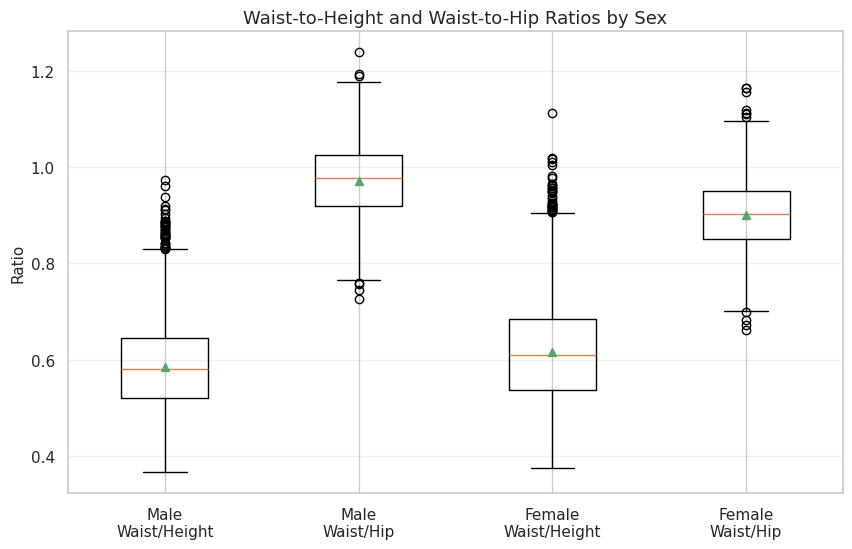

,Mean,Median,Std. Deviation,IQR
Male WHtR,0.5860,0.5819,0.0937,0.1231
Male WHR,0.9708,0.9767,0.0773,0.1054
Female WHtR,0.6156,0.6097,0.1080,0.1470
Female WHR,0.9000,0.9029,0.0723,0.1009


In [10]:
ratio_data = [male_whtr, male_whr, female_whtr, female_whr]
ratio_labels = [
    "Male\nWaist/Height",
    "Male\nWaist/Hip",
    "Female\nWaist/Height",
    "Female\nWaist/Hip",
]

plt.figure(figsize=(10, 6))
plt.boxplot(
    ratio_data,
    tick_labels=ratio_labels,
    showmeans=True
)
plt.ylabel("Ratio")
plt.title("Waist-to-Height and Waist-to-Hip Ratios by Sex")
plt.grid(axis="y", alpha=0.3)
plt.show()

ratio_summary = pd.DataFrame({
    "Mean": [x.mean() for x in ratio_data],
    "Median": [np.median(x) for x in ratio_data],
    "Std. Deviation": [x.std(ddof=1) for x in ratio_data],
    "IQR": [np.percentile(x, 75) - np.percentile(x, 25) for x in ratio_data],
}, index=["Male WHtR", "Male WHR", "Female WHtR", "Female WHR"])

display(ratio_summary.round(4))



The four boxes allow the central tendency and spread of each ratio to be compared. The waist-to-height ratio uses height as its denominator, whereas the waist-to-hip ratio uses hip circumference. Consequently, the two measures summarise different aspects of body shape and should not be interpreted as interchangeable.



## 11. Advantages and Disadvantages of BMI, Waist-to-Height Ratio, and Waist-to-Hip Ratio

### Body Mass Index (BMI)
**Advantages**
- Simple to calculate from weight and height.
- Inexpensive and practical for large populations.
- Provides a common screening measure for categorising body size.
- Easy to compare across studies and groups.

**Disadvantages**
- Does not distinguish fat mass from lean mass.
- Does not show where body fat is distributed.
- Can misclassify people with high muscle mass or unusual body composition.
- Does not directly measure metabolic or cardiovascular health.

### Waist-to-Height Ratio (WHtR)
**Advantages**
- Incorporates waist circumference, which reflects central body size.
- Relates waist size to overall stature.
- Easy and inexpensive to calculate.
- Can provide information that BMI alone does not capture.

**Disadvantages**
- Depends on accurate waist and height measurements.
- Does not distinguish visceral fat from other abdominal tissue.
- Does not fully account for age, sex, ethnicity, or individual body composition.
- A ratio is a screening indicator rather than a diagnosis.

### Waist-to-Hip Ratio (WHR)
**Advantages**
- Captures the relationship between abdominal and hip circumference.
- Provides information about body-fat distribution and body shape.
- Simple and inexpensive when measurements are available.

**Disadvantages**
- Requires two circumference measurements and therefore introduces additional measurement error.
- Can change because of hip circumference even when waist circumference remains the same.
- Does not directly measure total body fat or visceral fat.
- Interpretation can vary across populations and demographic groups.

Overall, these measures are best treated as complementary indicators rather than as complete assessments of individual health.



## 12. Standardised Measurements for the Five Lowest and Five Highest BMI Participants

The final task identifies the five female participants with the lowest BMI and the five with the highest BMI. `numpy.argsort` is used to obtain the required row indices. The corresponding rows from `zfemale` are then printed.

Because the data have been standardised, each value represents the number of standard deviations above or below the female sample mean for that measurement.


In [11]:

zfemale_array = np.asarray(zfemale)

bmi_values = np.asarray(female[:, 7]).ravel()
sorted_indices = np.argsort(bmi_values)

lowest_indices = sorted_indices[:5]
highest_indices = sorted_indices[-5:][::-1]

selected_indices = np.concatenate([lowest_indices, highest_indices])
selected_z = zfemale_array[selected_indices, :]

selected_labels = (
    [f"Lowest BMI #{i+1}" for i in range(5)]
    + [f"Highest BMI #{i+1}" for i in range(5)]
)

selected_df = pd.DataFrame(
    selected_z,
    index=selected_labels,
    columns=female_column_names[:8]  # Standardised body measurements + BMI
)

# BMI values are included separately for easy interpretation.
selected_df.insert(
    0,
    "Original BMI",
    bmi_values[selected_indices]
)

display(selected_df.round(3))

print("\nLowest five BMI values:")
for rank, idx in enumerate(lowest_indices, start=1):
    print(f"{rank}. Row {idx}: BMI = {bmi_values[idx]:.2f}")

print("\nHighest five BMI values:")
for rank, idx in enumerate(highest_indices, start=1):
    print(f"{rank}. Row {idx}: BMI = {bmi_values[idx]:.2f}")


,Original BMI,Weight (kg),Standing Height (cm),Upper Arm Length (cm),Upper Leg Length (cm),Arm Circumference (cm),Hip Circumference (cm),Waist Circumference (cm),BMI
Lowest BMI #1,14.203,-2.080,-1.223,-1.548,-1.169,-2.195,-2.041,-1.942,-2.050
Lowest BMI #2,14.633,-1.880,-0.189,-1.718,0.386,-2.444,-1.855,-2.057,-1.995
Lowest BMI #3,14.819,-1.537,1.807,0.626,0.573,-2.266,-1.676,-1.706,-1.971
Lowest BMI #4,15.045,-1.843,-0.260,-0.226,0.511,-2.302,-2.252,-1.856,-1.942
Lowest BMI #5,15.421,-1.611,0.887,-0.098,0.480,-2.213,-1.829,-1.712,-1.893
Highest BMI #1,67.037,4.363,-0.034,-0.056,-0.174,2.779,4.316,4.570,4.762
Highest BMI #2,65.333,4.804,0.887,2.118,1.817,3.778,4.021,4.082,4.543
Highest BMI #3,65.115,4.349,0.278,2.843,1.942,4.366,3.919,3.754,4.515
Highest BMI #4,64.707,4.456,0.505,1.692,-1.138,3.350,3.983,2.903,4.462
Highest BMI #5,64.199,4.247,0.292,1.862,-0.982,2.369,4.104,3.817,4.396



Lowest five BMI values:
1. Row 262: BMI = 14.20
2. Row 3478: BMI = 14.63
3. Row 2126: BMI = 14.82
4. Row 2753: BMI = 15.04
5. Row 1209: BMI = 15.42

Highest five BMI values:
1. Row 1096: BMI = 67.04
2. Row 1104: BMI = 65.33
3. Row 1472: BMI = 65.12
4. Row 3022: BMI = 64.71
5. Row 2268: BMI = 64.20



The lowest-BMI participants generally have BMI values substantially below the female sample average, while the highest-BMI participants have BMI values substantially above it. The standardised measurements make it possible to see which physical measurements are particularly low or high relative to the female sample.

This comparison also illustrates an important point: BMI is derived from weight and height, so extreme BMI values are naturally associated with unusual combinations of those measurements. Waist and hip measurements provide additional information about body size and distribution that BMI alone cannot describe.



# Overall Conclusion

The analysis demonstrates how NumPy matrices can be used to organise, transform, standardise, and analyse multidimensional body-measurement data. Visualisations show the distributions of male and female weights and the distributions of waist-based ratios, while descriptive statistics quantify location, dispersion, and shape.

Adding BMI and waist-based ratios provides derived measures that summarise body size and body proportions. Standardisation allows measurements expressed in different units to be compared on a common z-score scale. Pearson and Spearman correlation matrices further show the relationships among female height, weight, waist circumference, hip circumference, and BMI.

The findings should be interpreted as descriptive characteristics of the supplied NHANES excerpts. BMI, waist-to-height ratio, and waist-to-hip ratio are useful screening measures, but none of them alone provides a complete assessment of individual health or body composition.



## Reproducibility and Submission Checklist

Before submission, run **Kernel → Restart Kernel and Run All Cells** (or the equivalent command in your Jupyter environment) and confirm that:

1. Both CSV files load successfully.
2. The male and female matrix dimensions are displayed.
3. Both required weight histograms appear with identical x-axis limits.
4. The male/female weight boxplot appears.
5. The descriptive-statistics table is displayed.
6. BMI is added as the eighth female column.
7. `zfemale` has approximately zero column means and unit column standard deviations.
8. The scatterplot matrix and both correlation matrices appear.
9. The male and female matrices contain the two requested ratios.
10. The four-box ratio comparison appears.
11. The advantages/disadvantages discussion is present.
12. The ten selected standardised rows are printed.
13. There are no red error messages in the notebook.

The project instructions explicitly require a readable sectioned structure, rich Markdown formatting, formal language, and a brief explanation before and after each code chunk.
